In [36]:
import pandas as pd
import numpy as np



train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [37]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [38]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

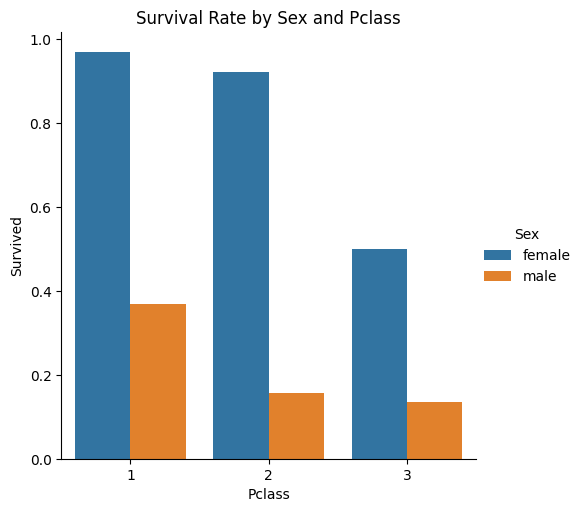

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    data=train_df,
    x="Pclass",
    y="Survived",
    hue="Sex",
    kind="bar",
    errorbar=None
)
plt.title("Survival Rate by Sex and Pclass")
plt.show()

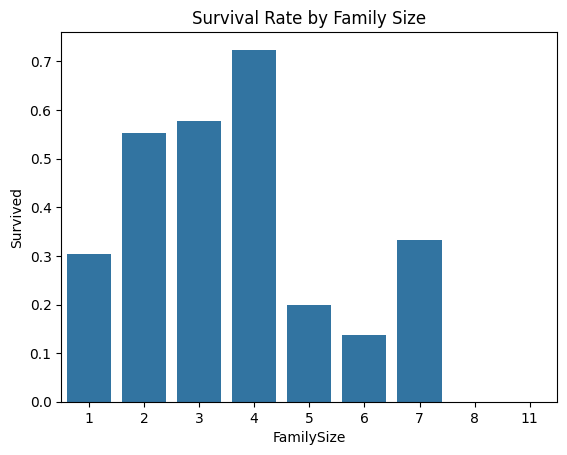

In [40]:
train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1

sns.barplot(data=train_df, x="FamilySize", y="Survived", errorbar=None)
plt.title("Survival Rate by Family Size")
plt.show()

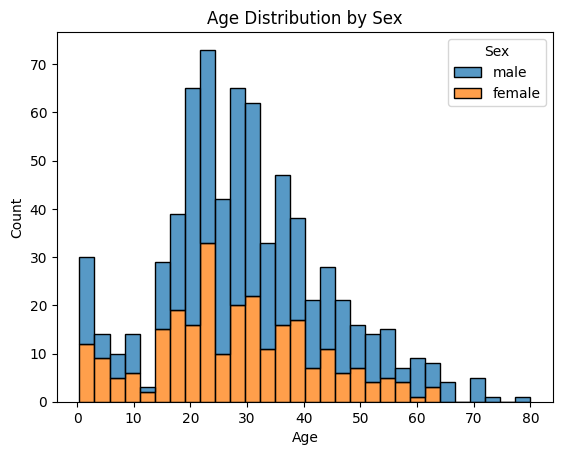

In [41]:
sns.histplot(
    data=train_df,
    x="Age",
    hue="Sex",
    multiple="stack",
    bins=30
)
plt.title("Age Distribution by Sex")
plt.show()

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize'],
      dtype='str')


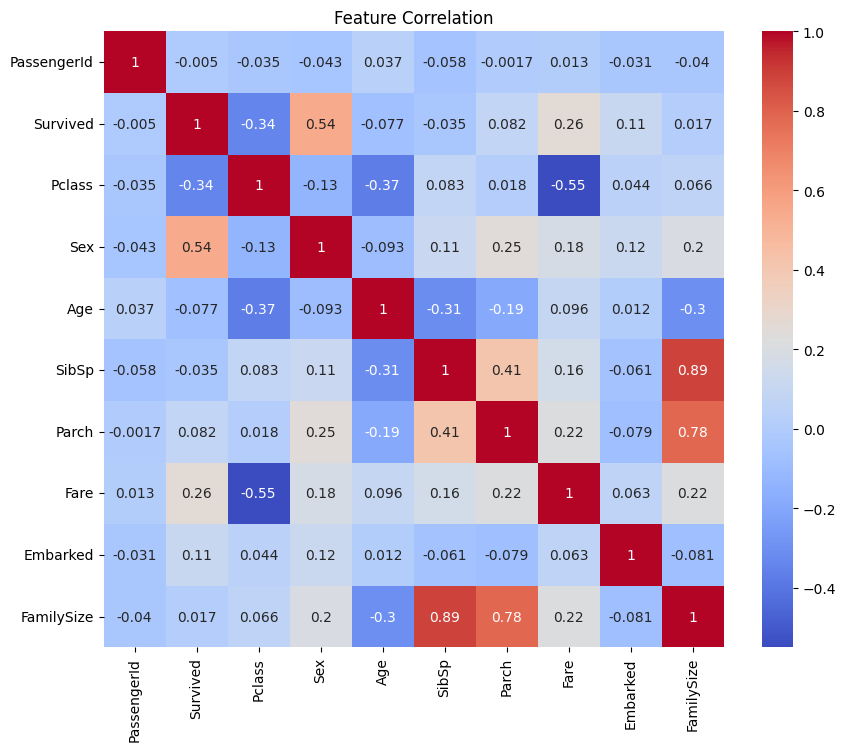

Survived       1.000000
Sex            0.543351
Fare           0.257307
Embarked       0.108669
Parch          0.081629
FamilySize     0.016639
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

In [42]:
import seaborn as sns

print(train_df.columns)
train_df["Sex"] = train_df["Sex"].map({"male": 0, "female": 1})
train_df["Embarked"] = train_df["Embarked"].map({"S": 0, "C": 1, "Q": 2})
corr = train_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()
corr["Survived"].sort_values(ascending=False)


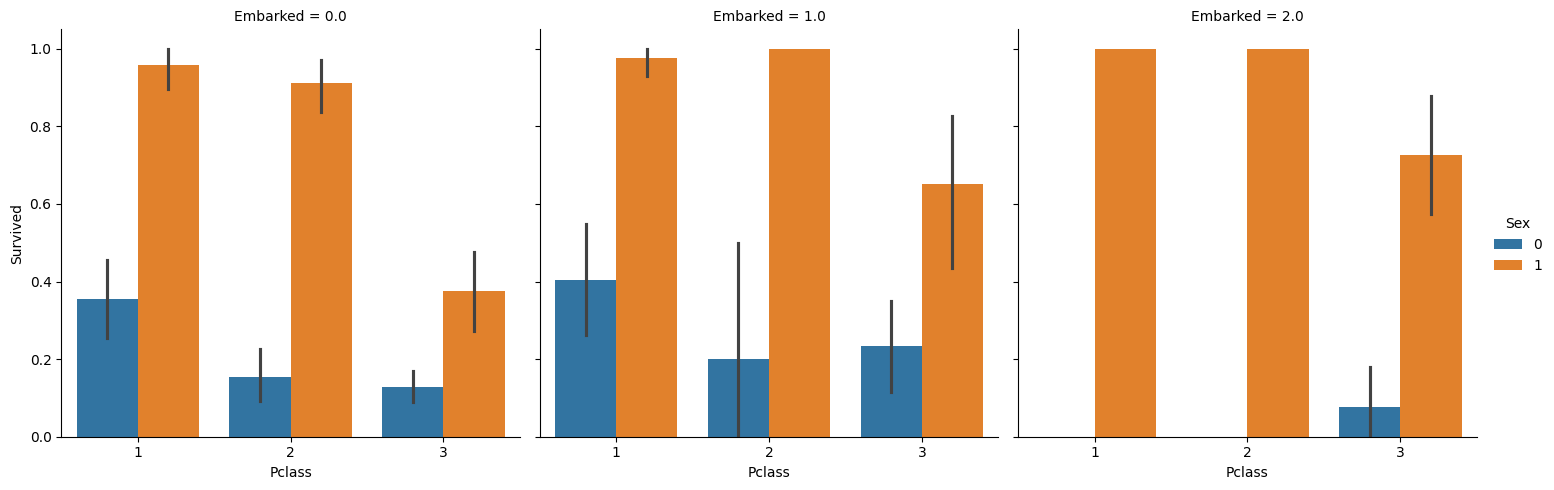

In [43]:
sns.catplot(
    data=train_df,
    x="Pclass",
    y="Survived",
    hue="Sex",
    col="Embarked",
    kind="bar"
)